In [138]:
import numpy as np
import pandas as pd
from plotnine import *

from sklearn.linear_model import LinearRegression

# Set the seed for reproducibility
np.random.seed(42)

In [139]:
from scipy.stats import f
from scipy.stats import t

In [140]:
!pip show plotnine

Name: plotnine
Version: 0.13.6
Summary: A Grammar of Graphics for Python
Home-page: 
Author: 
Author-email: Hassan Kibirige <has2k1@gmail.com>
License: The MIT License (MIT)
        
        Copyright (c) 2022 Hassan Kibirige
        
        Permission is hereby granted, free of charge, to any person obtaining a copy
        of this software and associated documentation files (the "Software"), to deal
        in the Software without restriction, including without limitation the rights
        to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
        copies of the Software, and to permit persons to whom the Software is
        furnished to do so, subject to the following conditions:
        
        The above copyright notice and this permission notice shall be included in all
        copies or substantial portions of the Software.
        
        THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
        IMPLIED, INCLUDING BUT NOT LIMIT

In [141]:
def generate_data(sigma):
    X = np.linspace(start=1, stop=10, num=10).reshape(-1, 1) #array w/ 1 column, the -1 means 'infer the # of rows'

    # Define parameters
    beta0 = 4
    beta1 = 3
    
    # Generate epsilon as a 1D array of N(0, sigma^2) RVs
    epsilon = sigma * np.random.randn(10)
    
    # Generate y using SLR model
    y = beta0 + beta1 * X.flatten() + epsilon

    return X, y 

In [142]:
X, y = generate_data(sigma = 2)

In [143]:
X

array([[ 1.],
       [ 2.],
       [ 3.],
       [ 4.],
       [ 5.],
       [ 6.],
       [ 7.],
       [ 8.],
       [ 9.],
       [10.]])

In [144]:
y

array([ 7.99342831,  9.7234714 , 14.29537708, 19.04605971, 18.53169325,
       21.53172609, 28.15842563, 29.53486946, 30.06105123, 35.08512009])

In [145]:
def ss_decomp(X, y):

    # Fit a linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Make predictions
    y_pred = model.predict(X)

    # Calculate the mean of y
    y_mean = np.mean(y)
    n = len(y)

    #calculate SS quantities
    SST = np.sum((y - y_mean) ** 2).round(4)
    SSR = np.sum((y_pred - y_mean) ** 2).round(4)
    SSE = np.sum((y - y_pred) ** 2).round(4)


    Fstat = (SSR/1) / (SSE/(n-2))

    # tstat = 

    # Output the sum of squares decomposition
    print(f"SST (Total Sum of Squares): {SST}")
    print(f"SSR (Regression Sum of Squares): {SSR}")
    print(f"SSE (Error Sum of Squares): {SSE}")
    print(f"SST = SSR + SSE: {np.isclose(SST, SSR + SSE)}")
    
    print(f"Coefficient of Determination, R^2 is: {np.round(1-SSE/SST, 4)}")

    print(f"The F-test will reject the null hypothesis? {Fstat > f.ppf(0.95, dfn=1, dfd=n-2)}")

    
    #make a ggplot
    df = pd.DataFrame({
        'X': X.flatten(),
        'y': y,
        'predicted': y_pred,
        'y_mean':  y_mean
    })

    gg1 = (
        ggplot(df, aes(x = 'X', y = 'y')) + 
        geom_point() + 
        #geom_smooth(method = "lm", formula = "y ~ x", se = False) +
        geom_hline(yintercept=y_mean, linetype='dashed') + 
        geom_segment(aes(xend = 'X', yend = 'y_mean'), color = "black") + #SST components
        ggtitle(f"R^2 is {np.round(1-SSE/SST, 4)}")
        )
    
    gg2 = (
        ggplot(df, aes(x = 'X', y = 'y')) + 
        geom_point() + 
        geom_smooth(method = "lm", formula = "y ~ x", se = False) +
        geom_hline(yintercept=y_mean, linetype='dashed') + 
        geom_segment(aes(xend = 'X', y = 'predicted', yend = 'y_mean'), color = "blue", linetype = "dashed") + #SSR components 
        geom_segment(aes(xend = 'X',  yend = 'predicted'), color = "red", linetype = "dashed") + #SSE components
        ggtitle(f"R^2 is {np.round(1-SSE/SST, 4)}")
        )

    display(gg1, gg2) #print the plots


    
    
    return Fstat 
    
    #gg1, gg2 #return the gg objects if you want to store the plots into variables

SST (Total Sum of Squares): 1033.645
SSR (Regression Sum of Squares): 536.8227
SSE (Error Sum of Squares): 496.8223
SST = SSR + SSE: True
Coefficient of Determination, R^2 is: 0.5193
The F-test will reject the null hypothesis? True


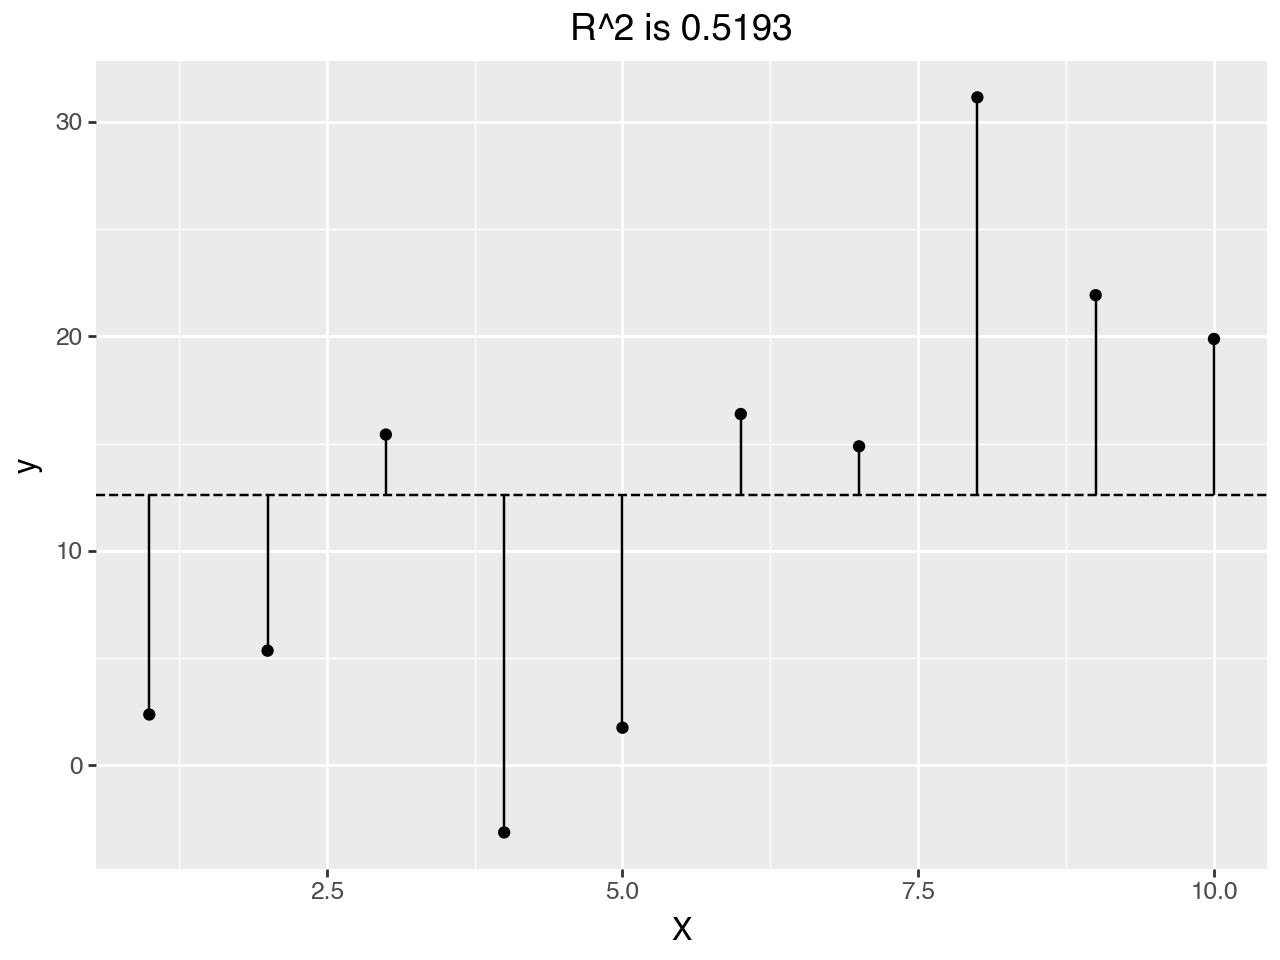

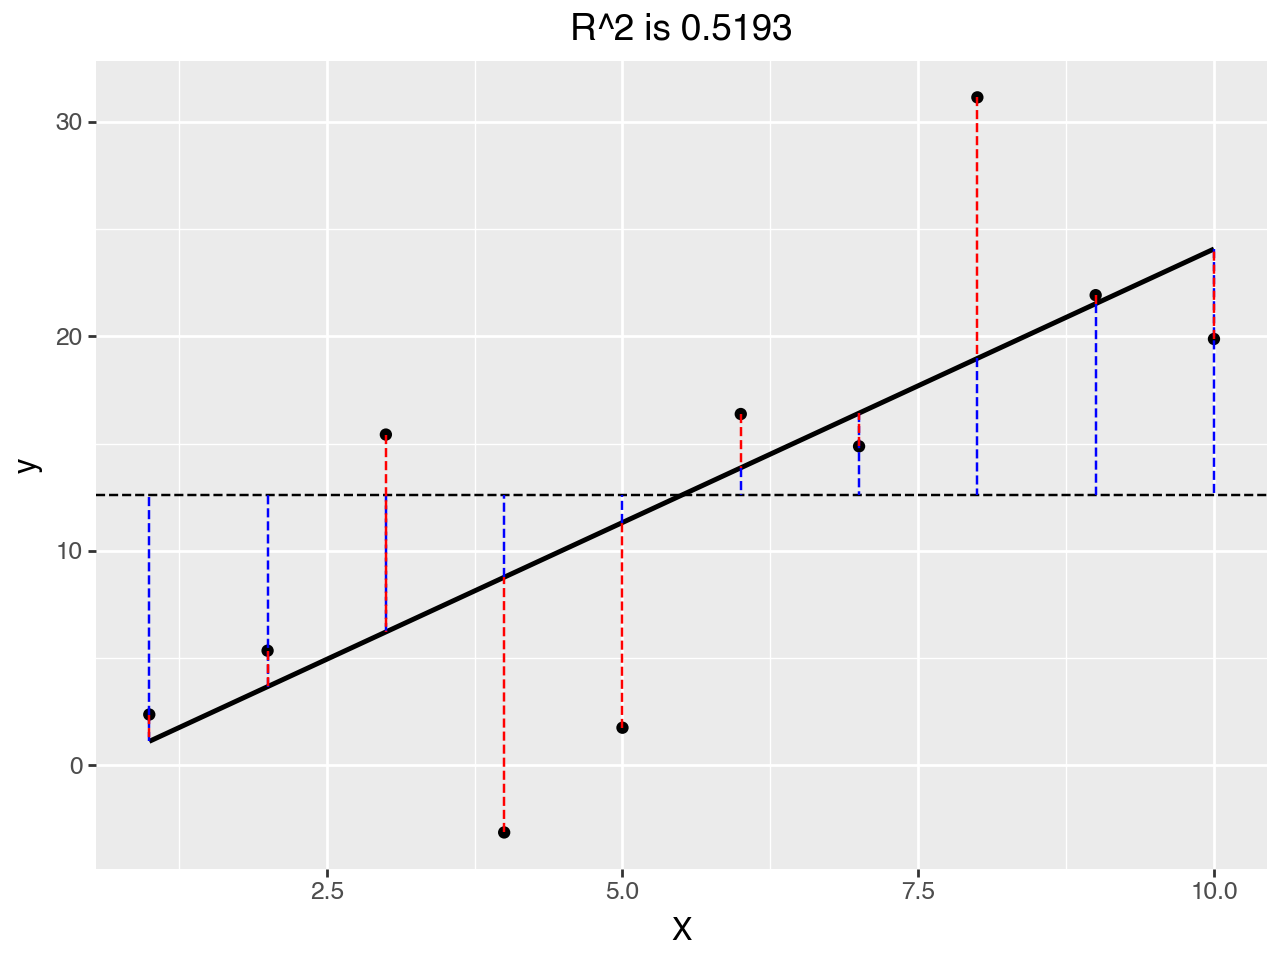

np.float64(8.64409991258444)

In [146]:
X, y = generate_data(sigma = 10)
ss_decomp(X, y)


In [147]:
f.ppf(0.95, dfn=1, dfd=8)

np.float64(5.317655071578714)

In [148]:
# Calculate the F-value at the 0.95 quantile
f_value = f.ppf(0.95, dfn=1, dfd=8)

f_value

np.float64(5.317655071578714)

SST (Total Sum of Squares): 660.2061
SSR (Regression Sum of Squares): 529.1792
SSE (Error Sum of Squares): 131.027
SST = SSR + SSE: True
Coefficient of Determination, R^2 is: 0.8015
The F-test will reject the null hypothesis? True


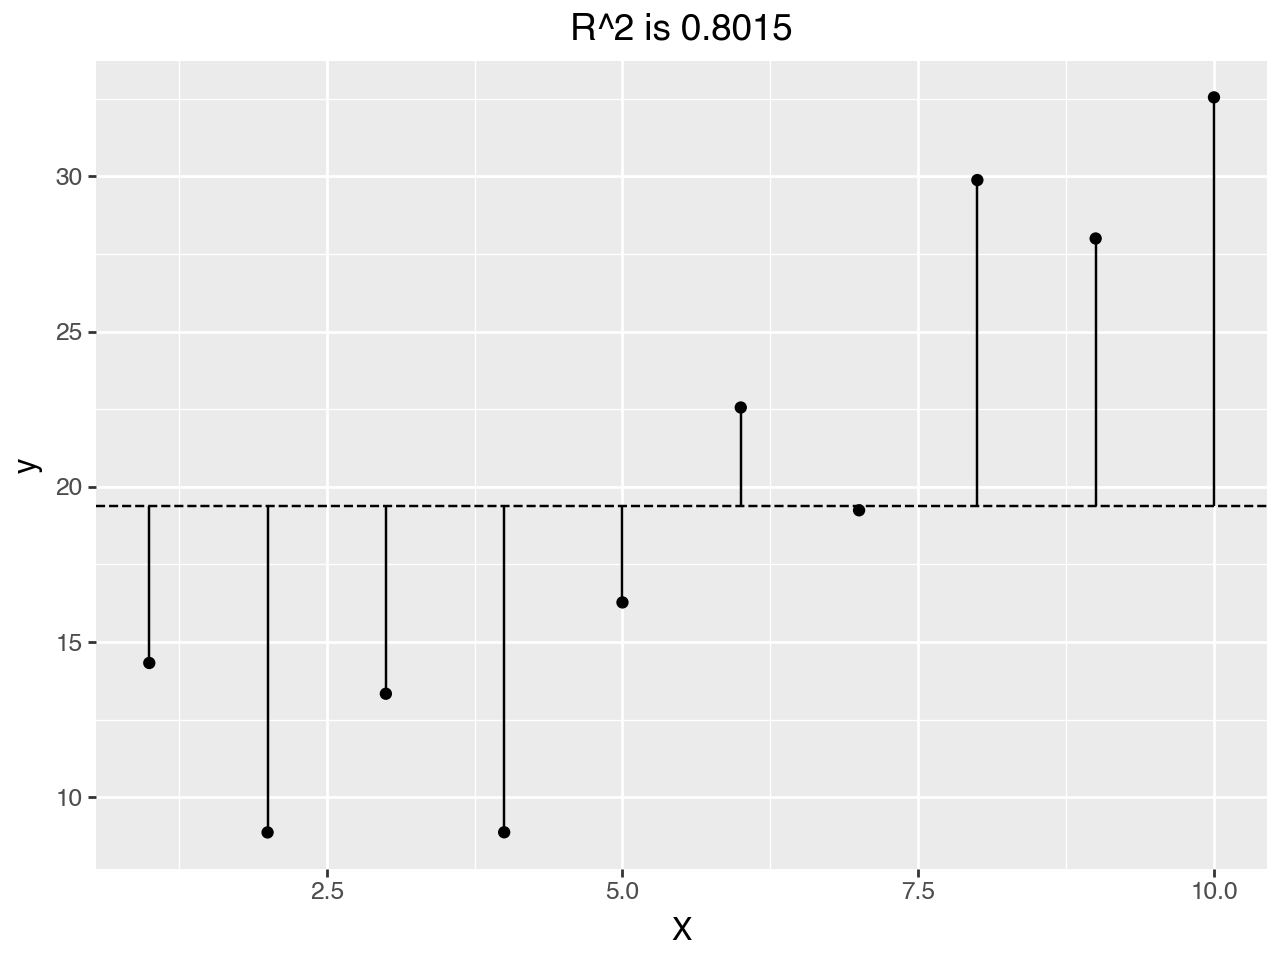

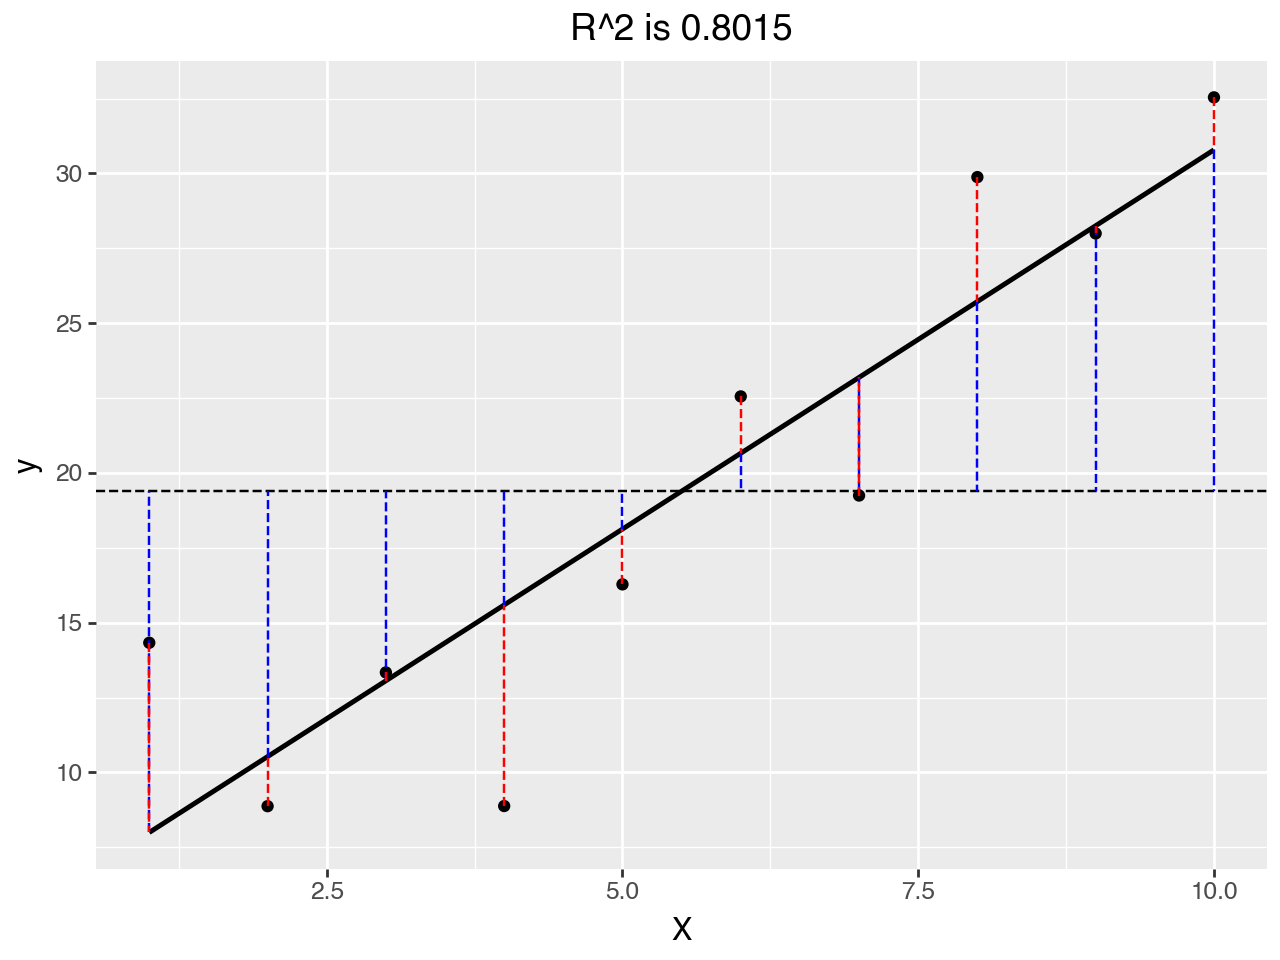

np.float64(32.3096277866394)

In [149]:
X, y = generate_data(sigma = 5)
ss_decomp(X, y)

SST (Total Sum of Squares): 1231.3861
SSR (Regression Sum of Squares): 211.99
SSE (Error Sum of Squares): 1019.396
SST = SSR + SSE: True
Coefficient of Determination, R^2 is: 0.1722
The F-test will reject the null hypothesis? False


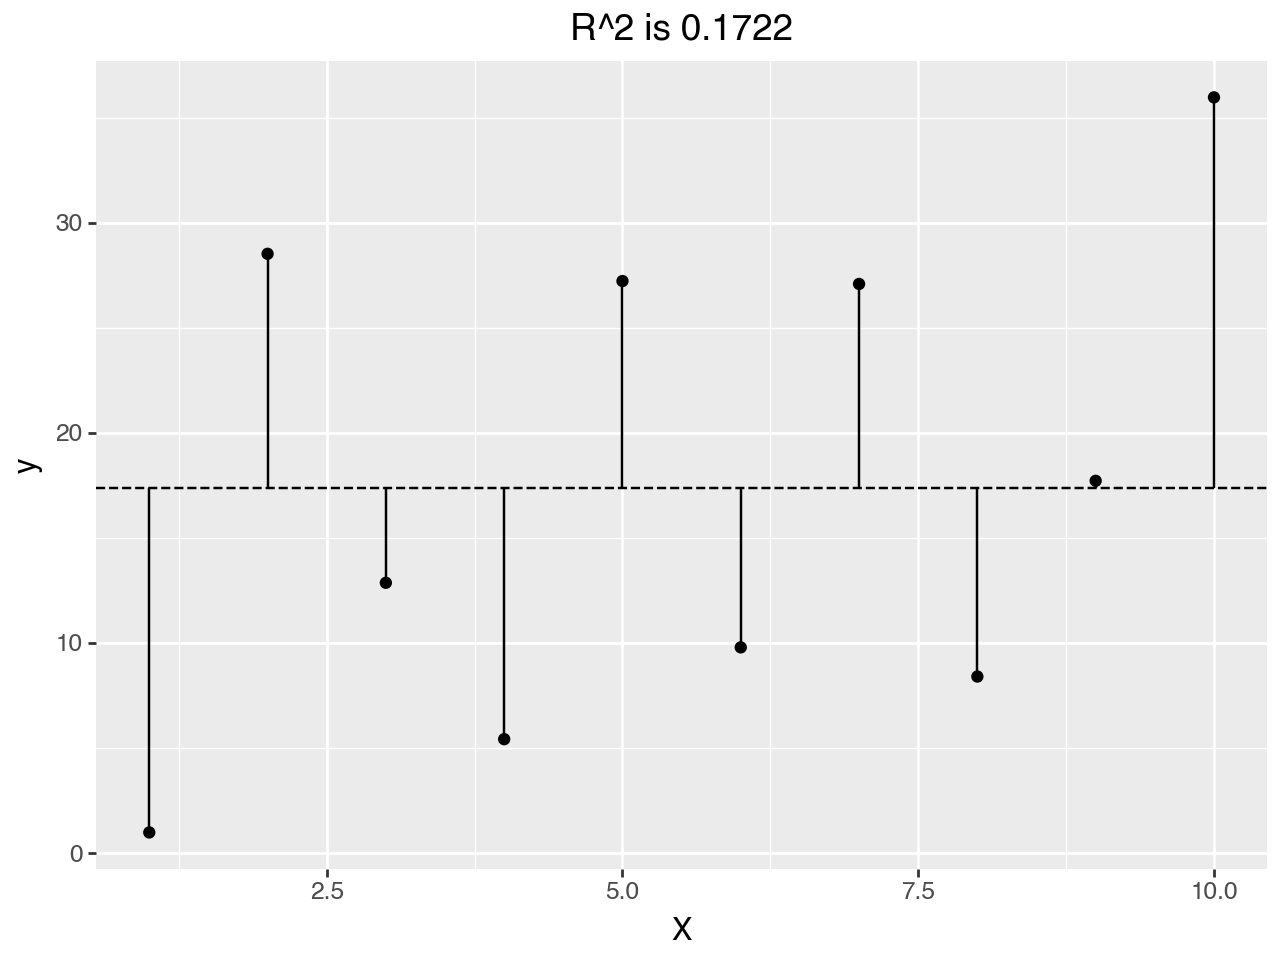

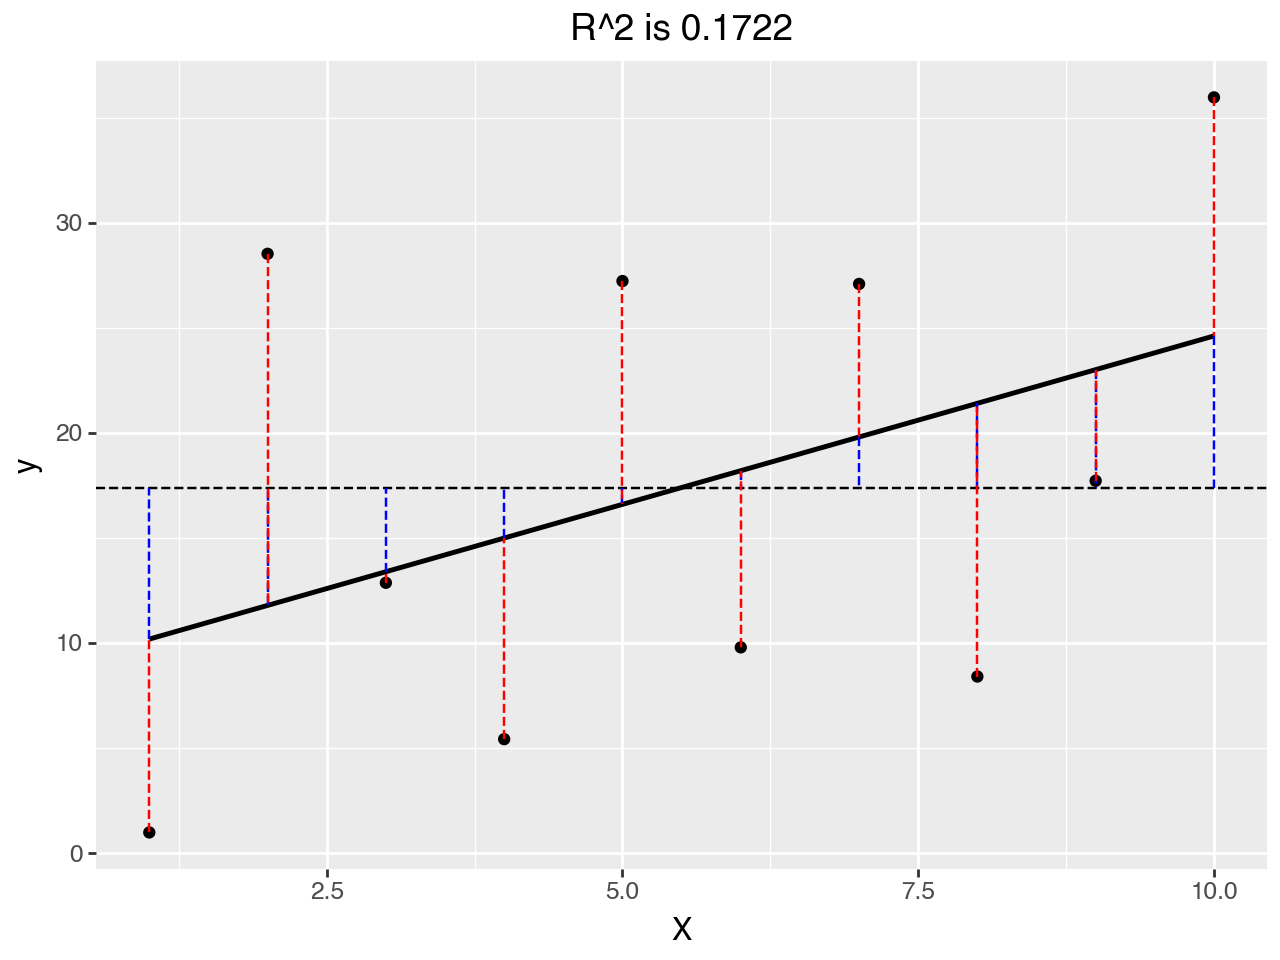

np.float64(1.6636518095028823)

In [150]:
X, y = generate_data(sigma = 10)
ss_decomp(X, y)

SST (Total Sum of Squares): 69191.6342
SSR (Regression Sum of Squares): 3161.3169
SSE (Error Sum of Squares): 66030.3174
SST = SSR + SSE: True
Coefficient of Determination, R^2 is: 0.0457
The F-test will reject the null hypothesis? False


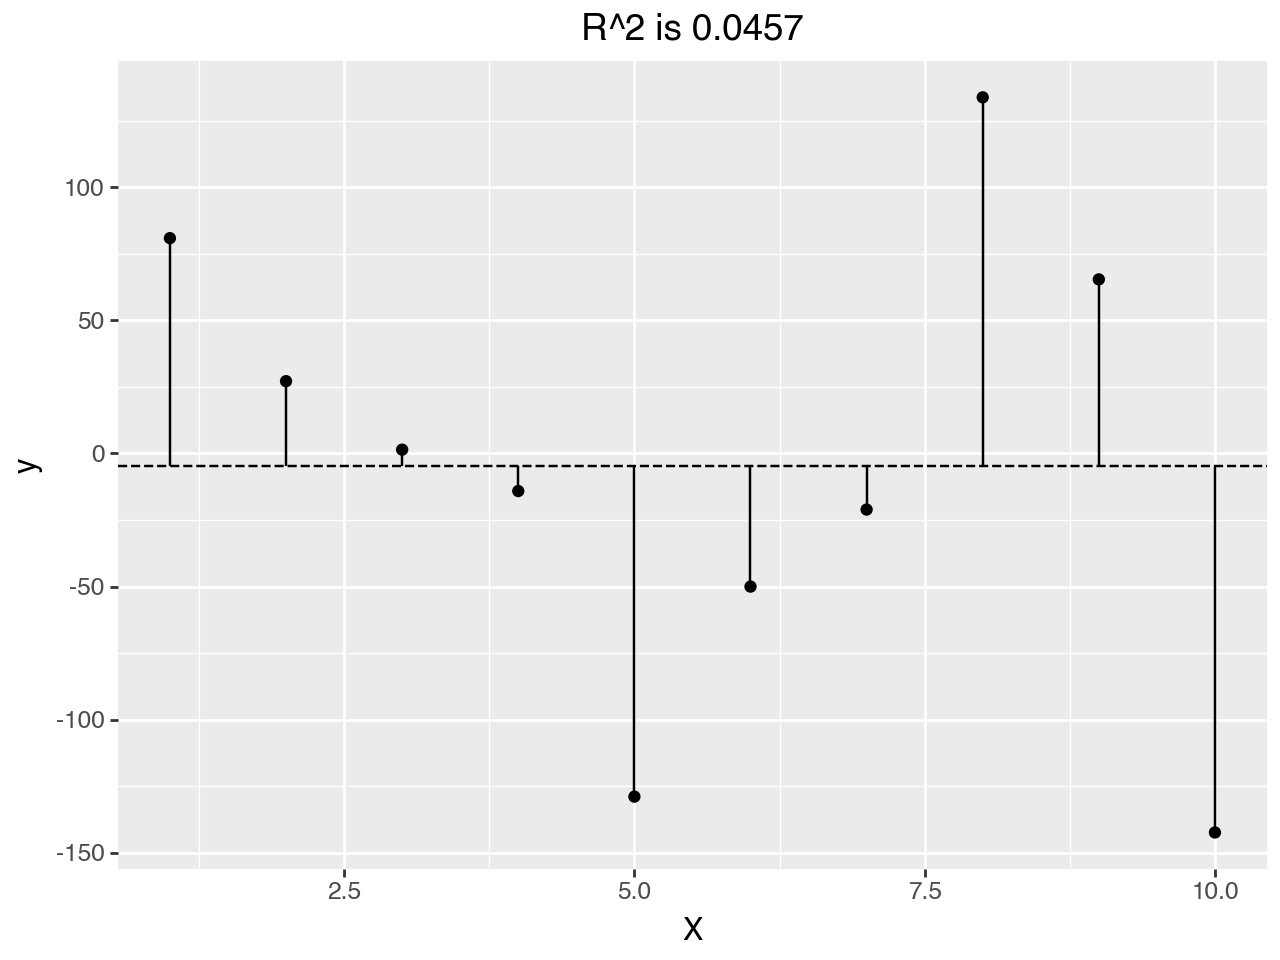

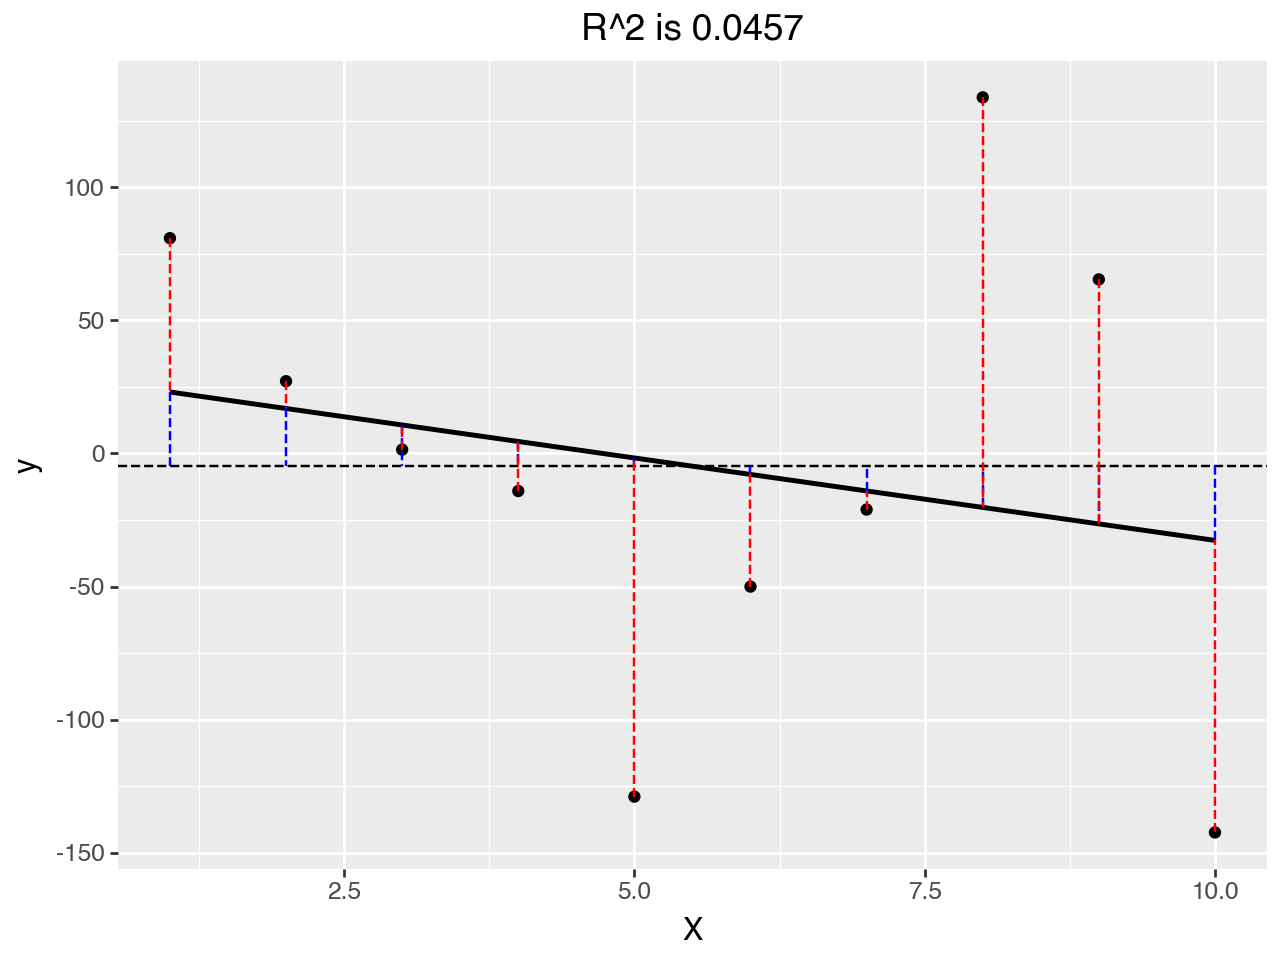

np.float64(0.3830139880563409)

In [151]:
X, y = generate_data(sigma = 100)
ss_decomp(X, y)

## Exercises:

1. Modify the data generation function to take the slope, intercept, and sample size as arguments.
2. Modify the SS decomposition function to conduct the F-test for testing whether the true slope is zero or not.
4. Holding the intercept, sample size, and error variance constant, compare how different values of the slope affect:
   
    a.  the SS decomposition,\
    b. the plots,\
    c. the coefficient of determination, and\
    d. the hypothesis test results.\
   What do you find?
5. Holding the slope, sample size, and error variance constant, compare how different values of the intercept affect:\
    a.  the SS decomposition,\
    b. the plots,\
    c. the coefficient of determination, and\
    d. the hypothesis test results.\
   What do you find?
6. Holding the intercept, slope, and error variance constant, compare how different values of the sample size affect:\
    a.  the SS decomposition,\
    b. the plots,\
    c. the coefficient of determination, and\
    d. the hypothesis test results.\
   What do you find?
7. Write a function which calculates the t-statistic for testing whether the true slope is zero or not. For each simulation you run, calculate both the t-stat and the F-stat. Repeat this $B=$100 times, then plot the ordered pairs $\{(t_b, F_b)\}_{b=1}^B$ as a scatter plot. What relationship do you observe between them? Can you prove this relation?

### Q1

1. Modify the data generation function to take the slope, intercept, and sample size as arguments.

In [152]:
def generate_data_tk(sigma, beta0, beta1, n):
    X = np.linspace(start=1, stop=10, num=n).reshape(-1, 1) #array w/ 1 column, the -1 means 'infer the # of rows'

    # Define parameters
    # beta0 = 4
    # beta1 = 3
    
    # Generate epsilon as a 1D array of N(0, sigma^2) RVs
    epsilon = sigma * np.random.randn(n)
    
    # Generate y using SLR model
    y = beta0 + beta1 * X.flatten() + epsilon

    return X, y 

### Q2

2. Modify the SS decomposition function to conduct the F-test for testing whether the true slope is zero or not.

In [153]:
def ss_decomp_tk(X, y):
    
    # Fit a linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Make predictions
    y_pred = model.predict(X)

    # Calculate the mean of y
    y_mean = np.mean(y)
    n = len(y)

    #calculate SS quantities
    SST = np.sum((y - y_mean) ** 2).round(4)
    SSR = np.sum((y_pred - y_mean) ** 2).round(4)
    SSE = np.sum((y - y_pred) ** 2).round(4)
    R2 = 1-SSE/SST.round(4)


    Fstat = (SSR/1) / (SSE/(n-2))

    # Find critical value of F
    a = 0.05
    df_num = 1
    df_den = n-2
    Fcrit = f.ppf(1 - a, df_num, df_den)

    # Output the sum of squares decomposition
    print(f"SST (Total Sum of Squares): {SST}")
    print(f"SSR (Regression Sum of Squares): {SSR}")
    print(f"SSE (Error Sum of Squares): {SSE}")
    print(f"SST = SSR + SSE: {np.isclose(SST, SSR + SSE)}")
    
    print(f"Coefficient of Determination, R^2 is: {np.round(1-SSE/SST, 4)}")

    print(f"The F-test will reject the null hypothesis? {Fstat > f.ppf(0.95, dfn=1, dfd=n-2)}")

    if Fstat > Fcrit:
        print(f"At alpha value of {a}, the F-test will reject the null hypothesis since F statistic: {Fstat:.2f} is greater than the critical value of F {Fcrit:.2f}")
    else:
        print(f"At alpha value of {a}, the F-test does not have enough evidence to reject the null hypothesis since F statistic: {Fstat:.2f} is smaller than the critical value of F {Fcrit:.2f}")

    
    #make a ggplot
    df = pd.DataFrame({
        'X': X.flatten(),
        'y': y,
        'predicted': y_pred,
        'y_mean':  y_mean
    })

    # gg1 = (
    #     ggplot(df, aes(x = 'X', y = 'y')) + 
    #     geom_point() + 
    #     #geom_smooth(method = "lm", formula = "y ~ x", se = False) +
    #     geom_hline(yintercept=y_mean, linetype='dashed') + 
    #     geom_segment(aes(xend = 'X', yend = 'y_mean'), color = "black") + #SST components
    #     ggtitle(f"R^2 is {np.round(1-SSE/SST, 4)}")
    #     )
    
    gg2 = (
        ggplot(df, aes(x = 'X', y = 'y')) + 
        geom_point() + 
        geom_smooth(method = "lm", formula = "y ~ x", se = False) +
        geom_hline(yintercept=y_mean, linetype='dashed') + 
        geom_segment(aes(xend = 'X', y = 'predicted', yend = 'y_mean'), color = "blue", linetype = "dashed") + #SSR components 
        geom_segment(aes(xend = 'X',  yend = 'predicted'), color = "red", linetype = "dashed") + #SSE components
        ggtitle(f"R^2 is {np.round(1-SSE/SST, 4)}")
        )

    # display(gg1, gg2) #print the plots
    display(gg2) #print the plots

    
    
    return Fstat, SSR, SSE, SST, R2
    
    #gg1, gg2 #return the gg objects if you want to store the plots into variables

SST (Total Sum of Squares): 2185.7364
SSR (Regression Sum of Squares): 1738.3869
SSE (Error Sum of Squares): 447.3494
SST = SSR + SSE: True
Coefficient of Determination, R^2 is: 0.7953
The F-test will reject the null hypothesis? True
At alpha value of 0.05, the F-test will reject the null hypothesis since F statistic: 108.81 is greater than the critical value of F 4.20


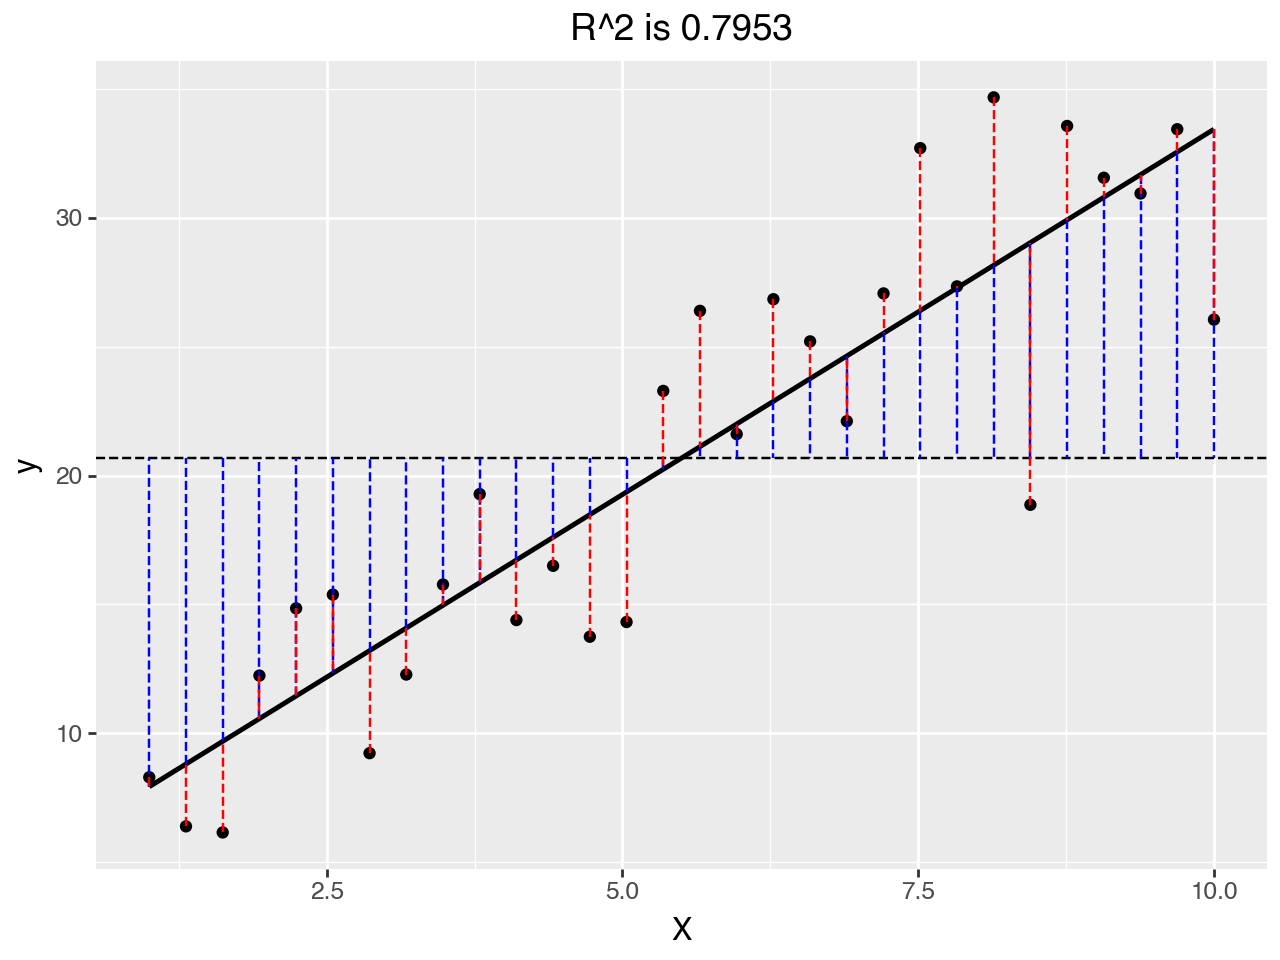

(np.float64(108.80719455530733),
 np.float64(1738.3869),
 np.float64(447.3494),
 np.float64(2185.7364),
 np.float64(0.7953324106237147))

In [154]:
X, y = generate_data_tk(sigma = 4, beta0 = 4, beta1 = 3, n = 30)
ss_decomp_tk(X, y)

### Q3

3. Holding the intercept, sample size, and error variance constant, compare how different values of the slope affect:
   
    a.  the SS decomposition,\
    b. the plots,\
    c. the coefficient of determination, and\
    d. the hypothesis test results.\
   What do you find?

SST (Total Sum of Squares): 1132.096
SSR (Regression Sum of Squares): 991.2279
SSE (Error Sum of Squares): 140.8681
SST = SSR + SSE: True
Coefficient of Determination, R^2 is: 0.8756
The F-test will reject the null hypothesis? True
At alpha value of 0.05, the F-test will reject the null hypothesis since F statistic: 56.29 is greater than the critical value of F 5.32


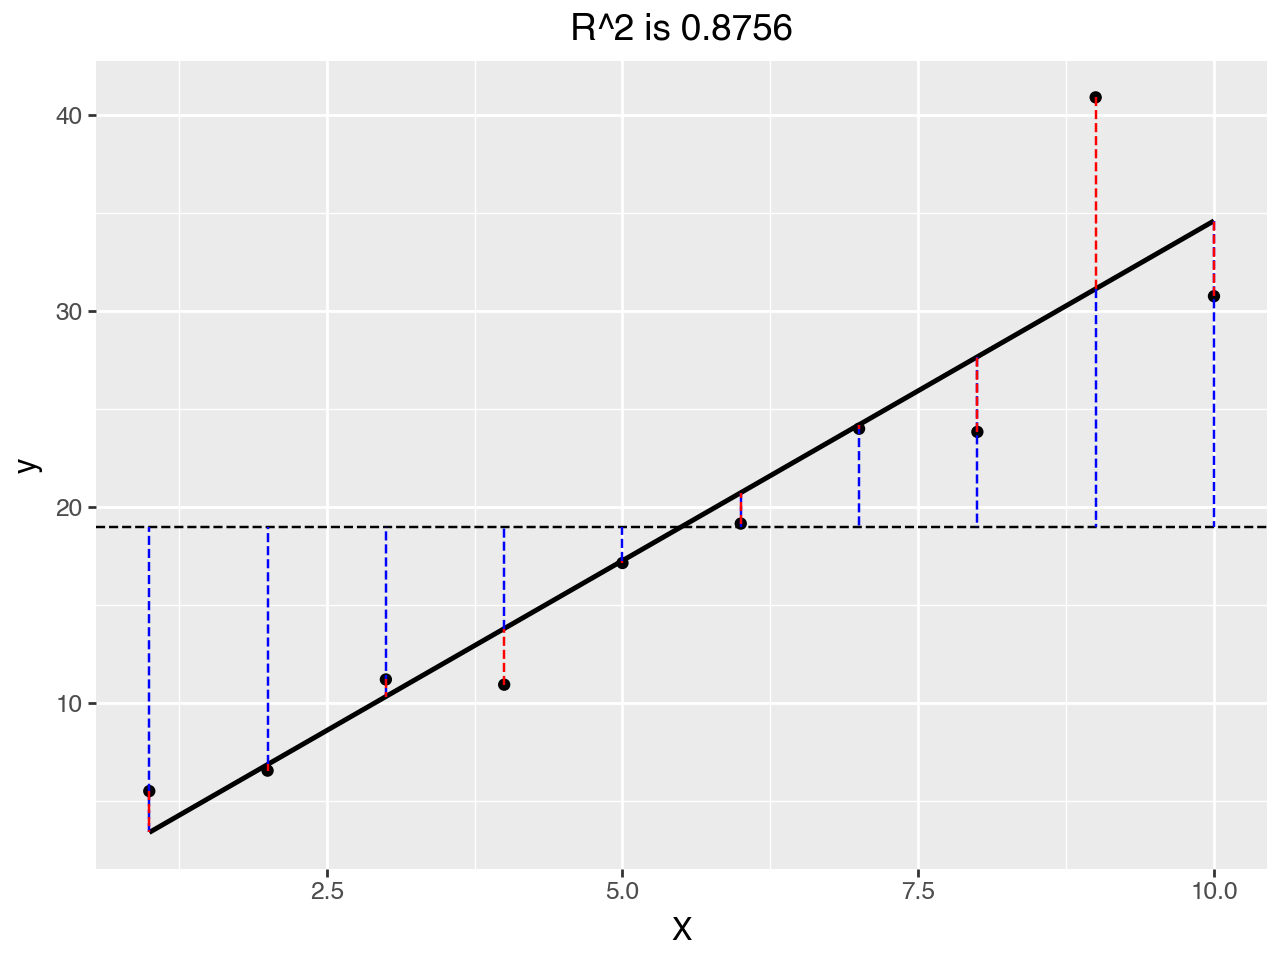

(np.float64(56.29254032673118),
 np.float64(991.2279),
 np.float64(140.8681),
 np.float64(1132.096),
 np.float64(0.8755687680196732))

In [163]:
X, y = generate_data_tk(sigma = 4, beta0 = 4, beta1 = 3, n = 10)
ss_decomp_tk(X, y)

SST (Total Sum of Squares): 37775.0142
SSR (Regression Sum of Squares): 37117.1164
SSE (Error Sum of Squares): 657.8978
SST = SSR + SSE: True
Coefficient of Determination, R^2 is: 0.9826
The F-test will reject the null hypothesis? True
At alpha value of 0.05, the F-test will reject the null hypothesis since F statistic: 2708.05 is greater than the critical value of F 4.04


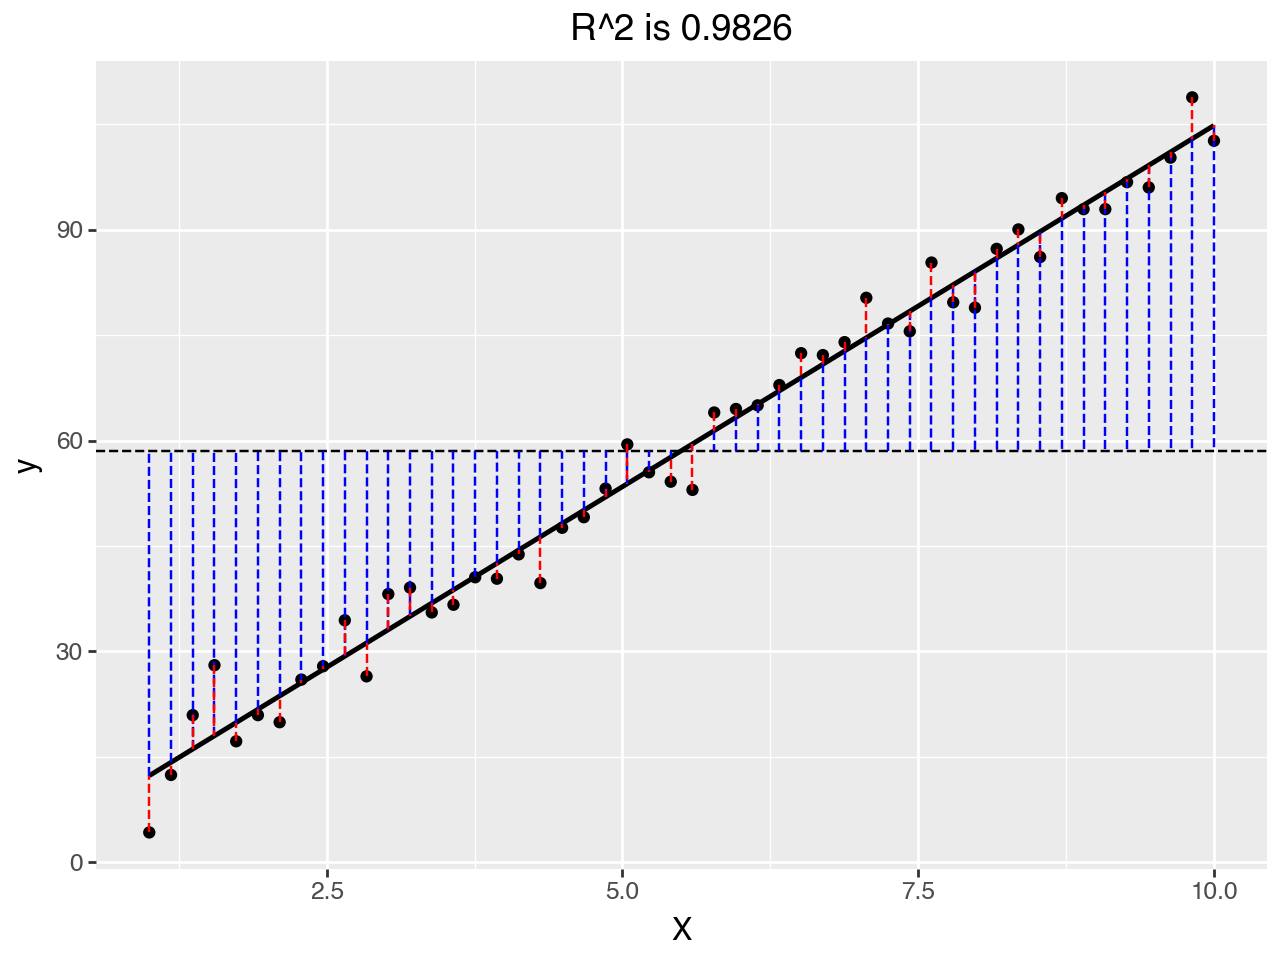

(np.float64(2708.052203852939),
 np.float64(37117.1164),
 np.float64(657.8978),
 np.float64(37775.0142),
 np.float64(0.9825837841776377))

In [162]:
X, y = generate_data_tk(sigma = 4, beta0 = 4, beta1 = 10, n = 50)
ss_decomp_tk(X, y)

SST (Total Sum of Squares): 1299.5861
SSR (Regression Sum of Squares): 409.504
SSE (Error Sum of Squares): 890.0821
SST = SSR + SSE: True
Coefficient of Determination, R^2 is: 0.3151
The F-test will reject the null hypothesis? True
At alpha value of 0.05, the F-test will reject the null hypothesis since F statistic: 22.08 is greater than the critical value of F 4.04


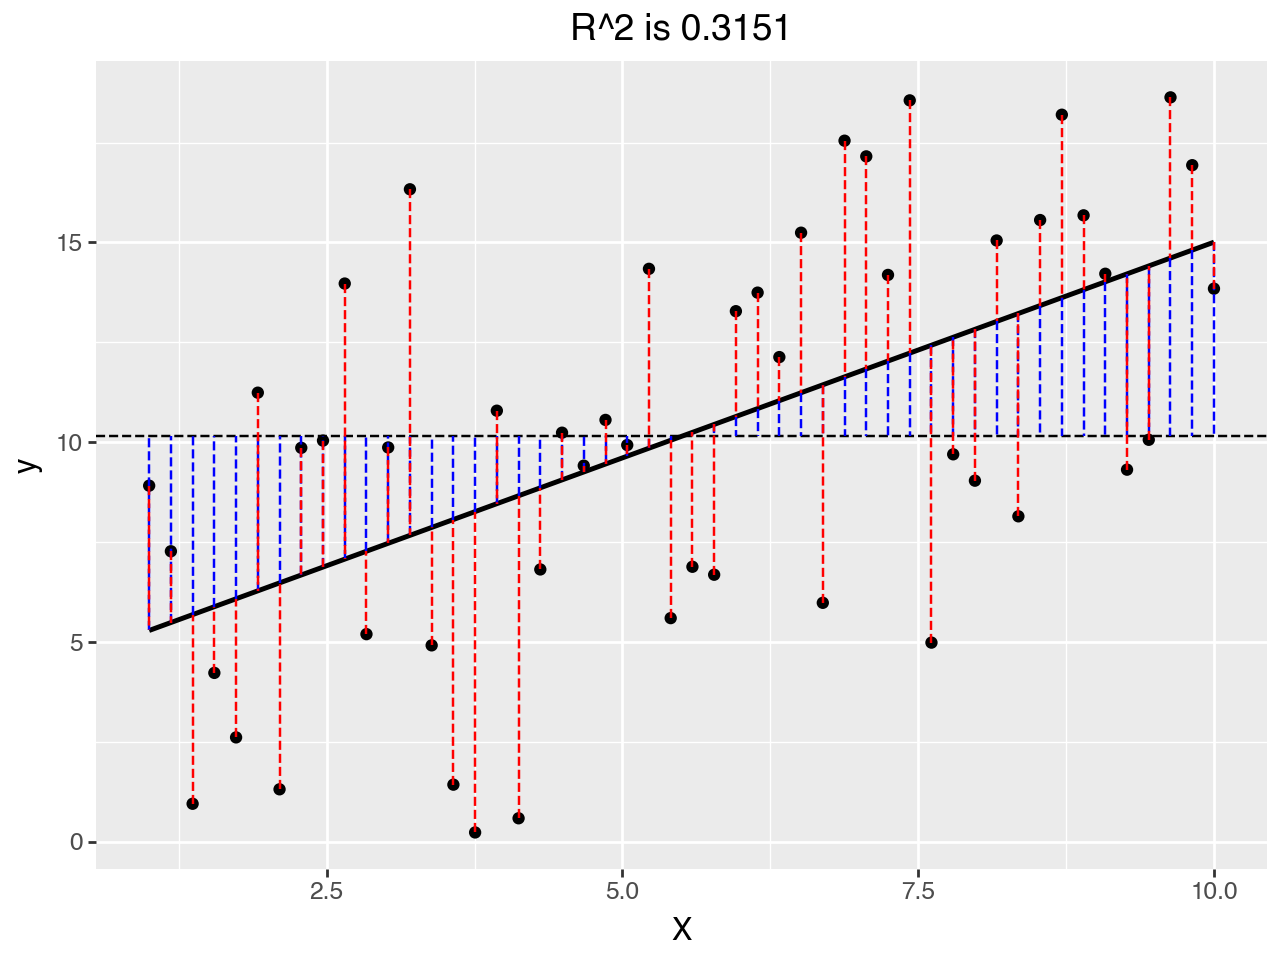

np.float64(22.08357184129419)

In [ ]:
X, y = generate_data_tk(sigma = 4, beta0 = 4, beta1 = 1, n = 50)
ss_decomp_tk(X, y)

SST (Total Sum of Squares): 3469.2475
SSR (Regression Sum of Squares): 2673.0378
SSE (Error Sum of Squares): 796.2097
SST = SSR + SSE: True
Coefficient of Determination, R^2 is: 0.7705
The F-test will reject the null hypothesis? True
At alpha value of 0.05, the F-test will reject the null hypothesis since F statistic: 161.15 is greater than the critical value of F 4.04


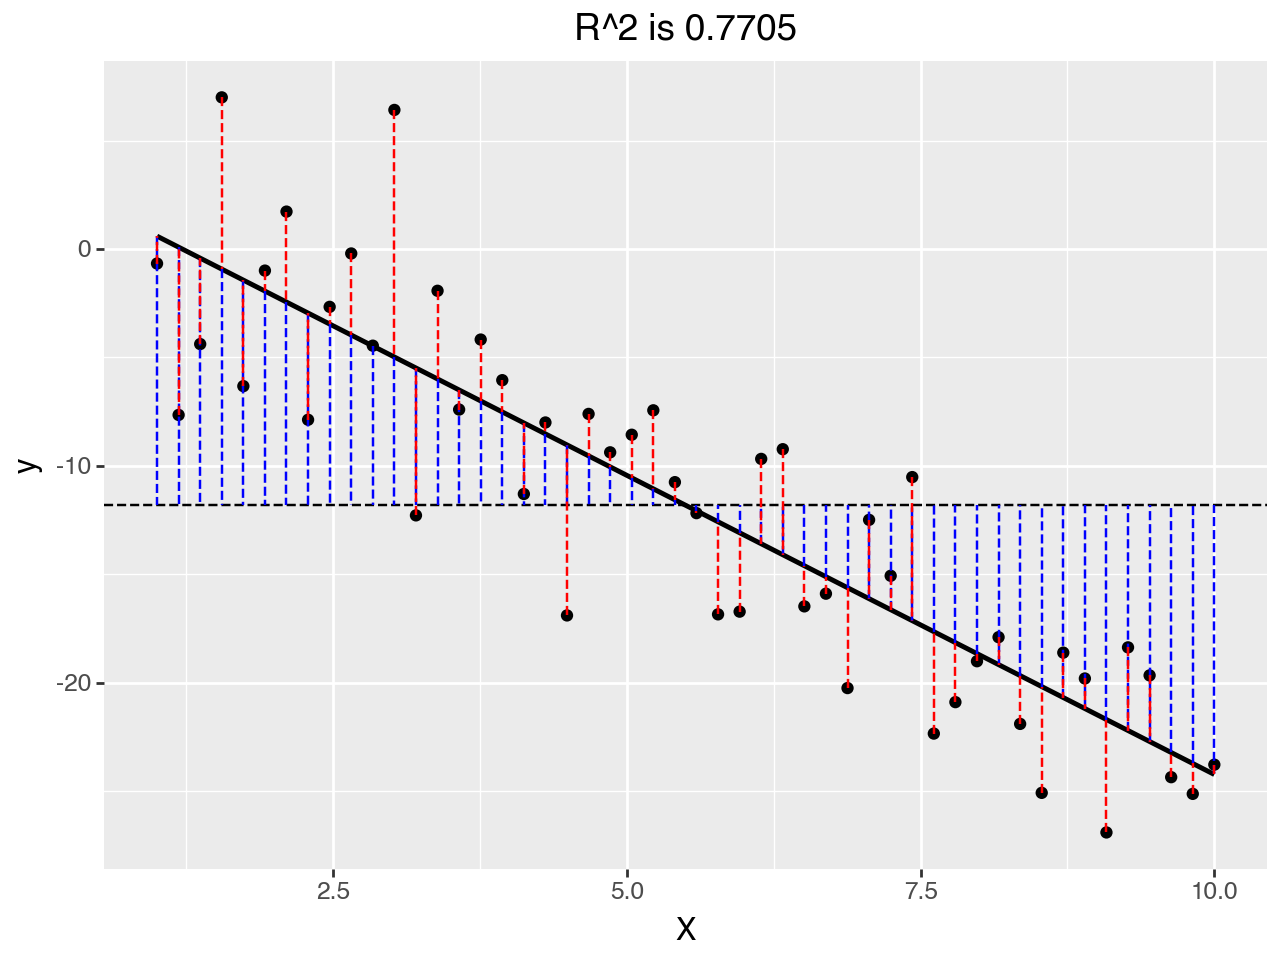

np.float64(161.14575645084454)

In [ ]:
X, y = generate_data_tk(sigma = 4, beta0 = 4, beta1 = -3, n = 50)
ss_decomp_tk(X, y)

SST (Total Sum of Squares): 964.9987
SSR (Regression Sum of Squares): 22.7357
SSE (Error Sum of Squares): 942.263
SST = SSR + SSE: True
Coefficient of Determination, R^2 is: 0.0236
The F-test will reject the null hypothesis? False
At alpha value of 0.05, the F-test does not have enough evidence to reject the null hypothesis since F statistic: 1.16 is smaller than the critical value of F 4.04


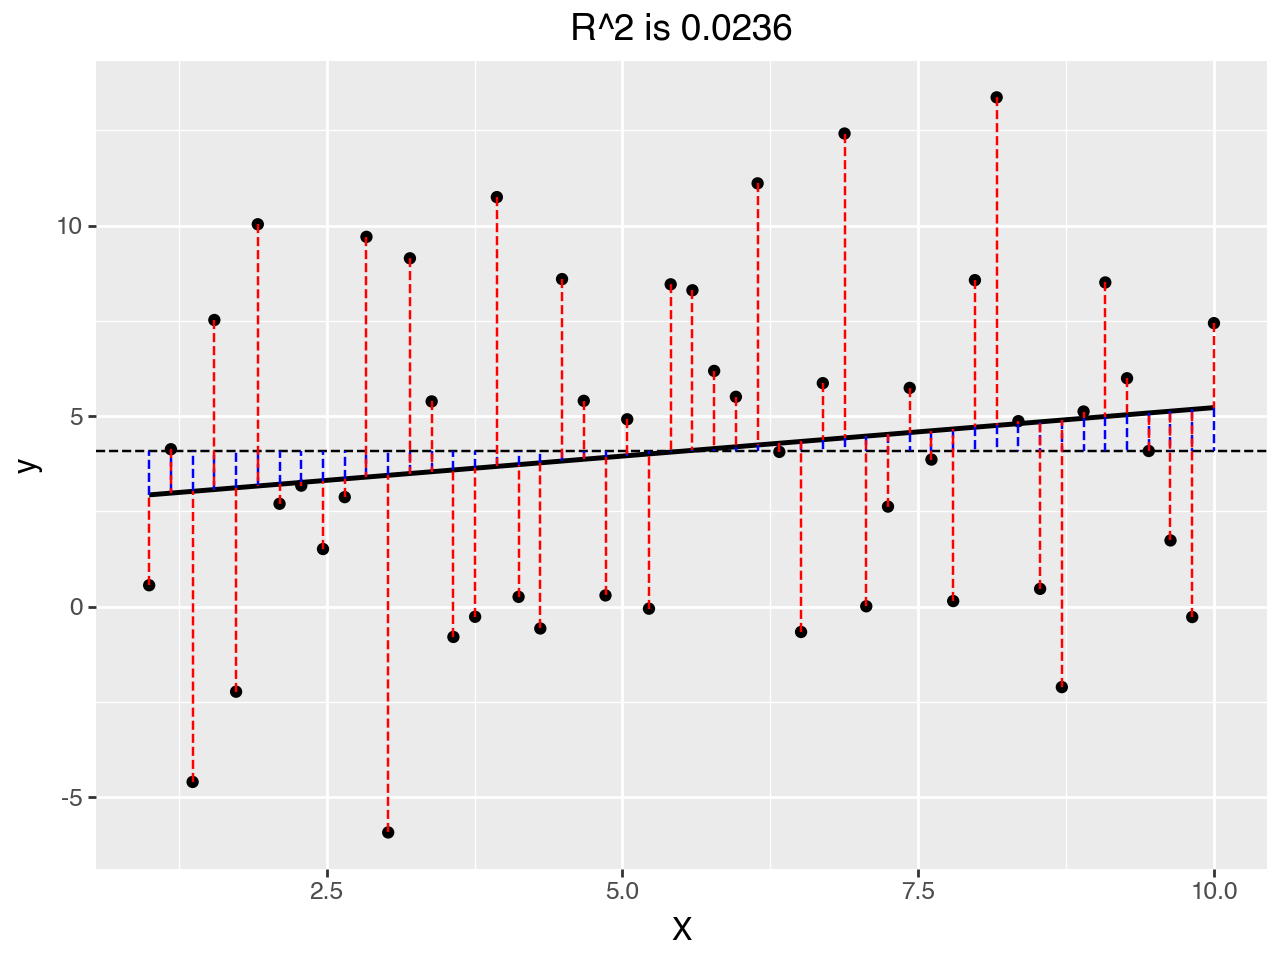

np.float64(1.1581836493632882)

In [ ]:
X, y = generate_data_tk(sigma = 4, beta0 = 4, beta1 = 0.01, n = 50)
ss_decomp_tk(X, y)

In [156]:
def ss_decomp_g(sigma=2,beta0=3,beta1=4,n=15):

    X,y = generate_data_tk(sigma,beta0,beta1,n)
   
    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)

    y_mean = np.mean(y)

    SST = np.sum((y - y_mean) ** 2).round(4)
    SSR = np.sum((y_pred - y_mean) ** 2).round(4)
    SSE = np.sum((y - y_pred) ** 2).round(4)

    F = (SSR/1)/(SSE/(n-2))
    R2 = (1-SSE/SST).round(4)

    return SSR, SSE, SST, F, R2

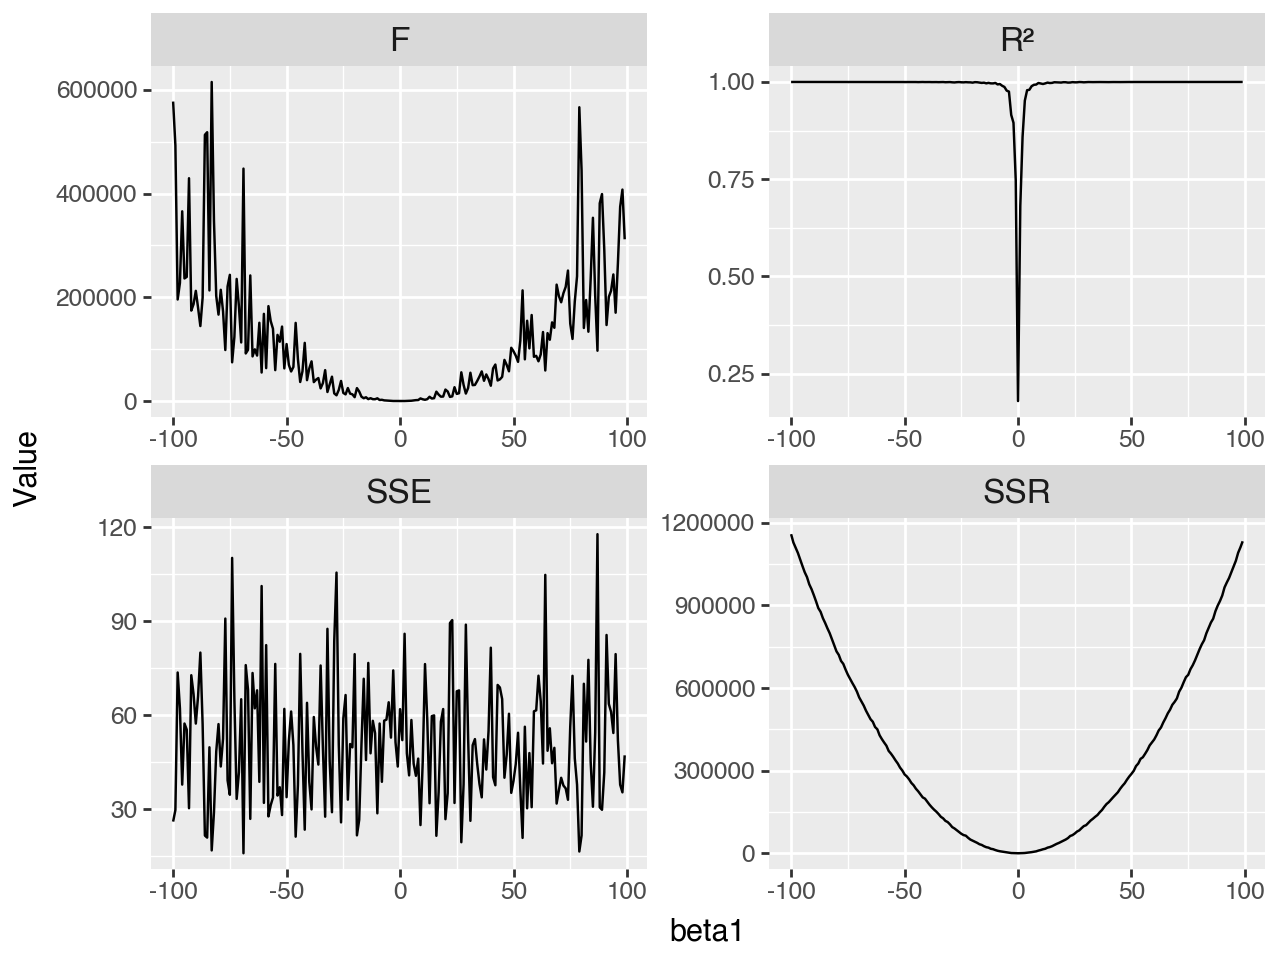

In [157]:
x_vals = list(range(-100, 100))
records = []

for x in x_vals:
    ssr, sse, _, fval, r2 = ss_decomp_g(beta1=x)
    records.append({"x": x, "value": ssr, "metric": "SSR"})
    records.append({"x": x, "value": sse, "metric": "SSE"})
    records.append({"x": x, "value": fval, "metric": "F"})
    records.append({"x": x, "value": r2,  "metric": "R²"})

df = pd.DataFrame(records)

# Plot with facets (2x2 layout)
(
    ggplot(df, aes("x", "value"))
    + geom_line()
    + facet_wrap("~metric", ncol=2, scales="free")
    + labs(x="beta1", y="Value")
    + theme(strip_text=element_text(size=12))
)


a.  the SS decomposition
- It seems that around beta1 = 0, SSE takes over completely and therefore tanks the R^2 value.
- for other values of beta1, SSR becomes much much higher than SSE.

b. the plots
- SSE seems to have a lot of noise.
- SSR is a pretty parabola. Something like y = x^2

c. the coefficient of determination
- R^2 is really high (very close to 1) for most values of beta1 except for around when beta1 is 0.

d. the hypothesis test results
- it's really interesting to see that for slopes close to 0, the F statistic does not have enough evidence to reject the null hypothesis. this makes sense because the null hypothesis postulates that slope is 0.
- for slopes far away from 0, the F statistic is higher than the f critical value and therefore we can reject the null hypothesis.

### Q4

4. Holding the slope, sample size, and error variance constant, compare how different values of the intercept affect:\
    a.  the SS decomposition,\
    b. the plots,\
    c. the coefficient of determination, and\
    d. the hypothesis test results.\
   What do you find?


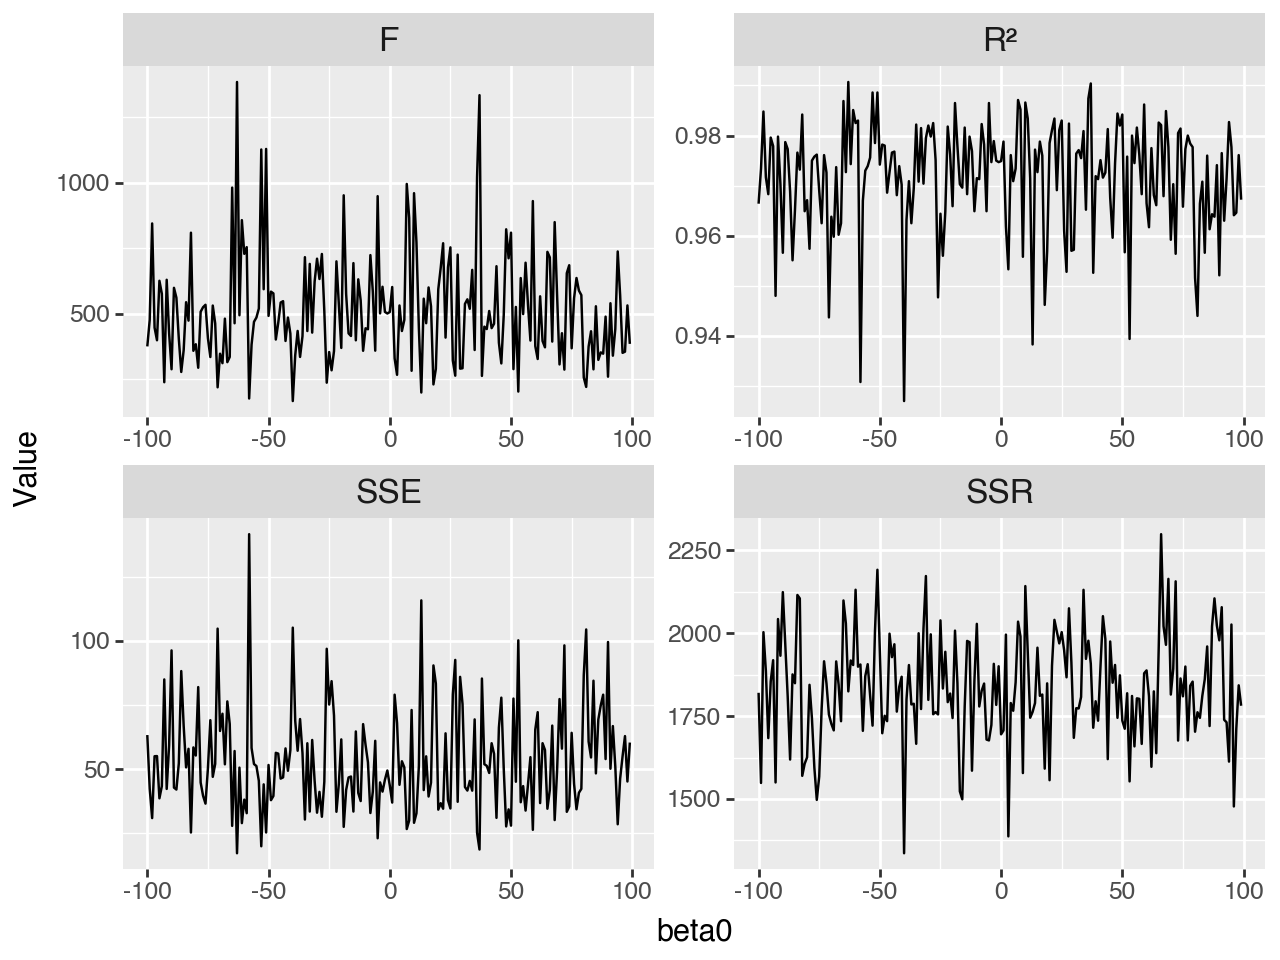

In [159]:
x_vals = list(range(-100, 100))
records = []

for x in x_vals:
    ssr, sse, _, fval, r2 = ss_decomp_g(beta0=x)
    records.append({"x": x, "value": ssr, "metric": "SSR"})
    records.append({"x": x, "value": sse, "metric": "SSE"})
    records.append({"x": x, "value": fval, "metric": "F"})
    records.append({"x": x, "value": r2,  "metric": "R²"})

df = pd.DataFrame(records)

# Plot with facets (2x2 layout)
(
    ggplot(df, aes("x", "value"))
    + geom_line()
    + facet_wrap("~metric", ncol=2, scales="free")
    + labs(x="beta0", y="Value")
    + theme(strip_text=element_text(size=12))
)


a. the SS decomposition
- SSE and SSR don't seem to be affected significantly by changes in intercept. There seems to be a lot of noise.

b. the plots
- All of these plots seem to show a lot of noise.

c. the coefficient of determination
- R^2 is really high ranging from ~0.99 to 0.93. There seems to be a lot of noise on the plot but all of the R^2 values are high.

d. the hypothesis test results
- Intercept doesn't seem to have a lot of impact on F statistic. It seems like for all values of beta0, the F statistic would reject the null hypothesis.



### Q5

5. Holding the intercept, slope, and error variance constant, compare how different values of the sample size affect:\
    a.  the SS decomposition,\
    b. the plots,\
    c. the coefficient of determination, and\
    d. the hypothesis test results.\
   What do you find?


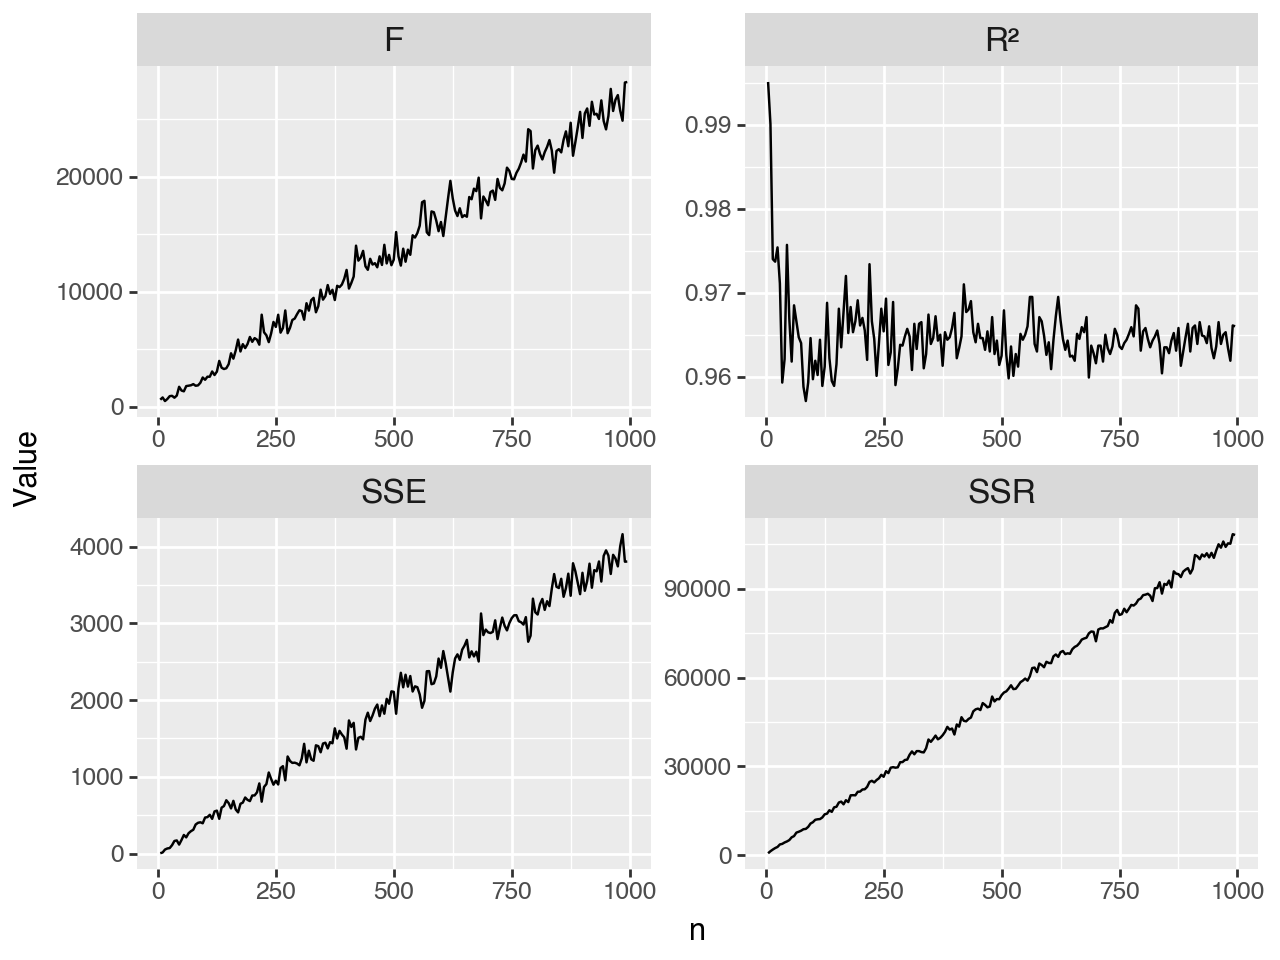

In [160]:
x_vals = list(range(5, 1000, 5))
records = []

for x in x_vals:
    ssr, sse, _, fval, r2 = ss_decomp_g(n=x)
    records.append({"x": x, "value": ssr, "metric": "SSR"})
    records.append({"x": x, "value": sse, "metric": "SSE"})
    records.append({"x": x, "value": fval, "metric": "F"})
    records.append({"x": x, "value": r2,  "metric": "R²"})

df = pd.DataFrame(records)

# Plot with facets (2x2 layout)
(
    ggplot(df, aes("x", "value"))
    + geom_line()
    + facet_wrap("~metric", ncol=2, scales="free")
    + labs(x="n", y="Value")
    + theme(strip_text=element_text(size=12))
)


a. SS Decomposition:
- SSE generally increases with larger sample size (n)
- SSR generally increases with larger sample size (n). It seems to increase at a faster pace than SSE.
- F statistic generally increases with larger sample size (n)

b. Plots:
- It's interesting to see 3 of 4 graphs to be so colinear.
- F statistic is increasing with increasing value of (n)

c. The coefficient of determination
- R^2 starts off relatively high but eventually seems to converge on a value (with a decent amount of noise)

d. hypothesis test results
- as sample size n increases, the f statistic will have enough evidence to reject null hypothesis.

### Q6

6. Write a function which calculates the t-statistic for testing whether the true slope is zero or not. For each simulation you run, calculate both the t-stat and the F-stat. Repeat this $B=$100 times, then plot the ordered pairs $\{(t_b, F_b)\}_{b=1}^B$ as a scatter plot. What relationship do you observe between them? Can you prove this relation?

In [ ]:
def ss_decomp_ft(sigma = 4, beta0 = 4, beta1 = 0.01, n = 50): # Calculates both f statistic and t statistic

    X,y = generate_data_tk(sigma,beta0,beta1,n)

    # Fit a linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Make predictions
    y_pred = model.predict(X)

    # Calculate the mean of y
    y_mean = np.mean(y)
    x_mean = np.mean(X)
    n = len(y)

    #calculate SS quantities
    SST = np.sum((y - y_mean) ** 2).round(4)
    SSR = np.sum((y_pred - y_mean) ** 2).round(4)
    SSE = np.sum((y - y_pred) ** 2).round(4)
    SSX = np.sum((X - x_mean) ** 2).round(4)


    # F Statistic
    Fstat = (SSR/1) / (SSE/(n-2))

    # Find critical value of F
    a = 0.05
    df_num = 1
    df_den = n-2
    Fcrit = f.ppf(1 - a, df_num, df_den)

    # t statistic
    beta1_hat = model.coef_[0]
    e = y-y_pred
    sigma_hat = np.sqrt(SSE / (n-2))


    tstat = beta1_hat / (sigma_hat/np.sqrt(SSX))
    df_t = n-1
    tcrit = t.ppf(1 - a/2, df_t)


    # Output the sum of squares decomposition
    # print(f"SST (Total Sum of Squares): {SST}")
    # print(f"SSR (Regression Sum of Squares): {SSR}")
    # print(f"SSE (Error Sum of Squares): {SSE}")
    # print(f"SST = SSR + SSE: {np.isclose(SST, SSR + SSE)}")
    
    # print(f"Coefficient of Determination, R^2 is: {np.round(1-SSE/SST, 4)}")

    # print(f"The F-test will reject the null hypothesis? {Fstat > f.ppf(0.95, dfn=1, dfd=n-2)}")
    # print(f"F statistic: {Fstat:.2f}, F critical value: {Fcrit:.2f}")
    # print(f"The t-test will reject null hypothesis? {tstat > tcrit}")
    # print(f"t statistic: {tstat:.2f}, t critical value: {tcrit:.2f}")

    # if Fstat > Fcrit:
    #     print(f"At alpha value of {a}, the F-test will reject the null hypothesis since F statistic: {Fstat:.2f} is greater than the critical value of F {Fcrit:.2f}")
    # else:
    #     print(f"At alpha value of {a}, the F-test does not have enough evidence to reject the null hypothesis since F statistic: {Fstat:.2f} is smaller than the critical value of F {Fcrit:.2f}")
    
    return Fstat, tstat
    

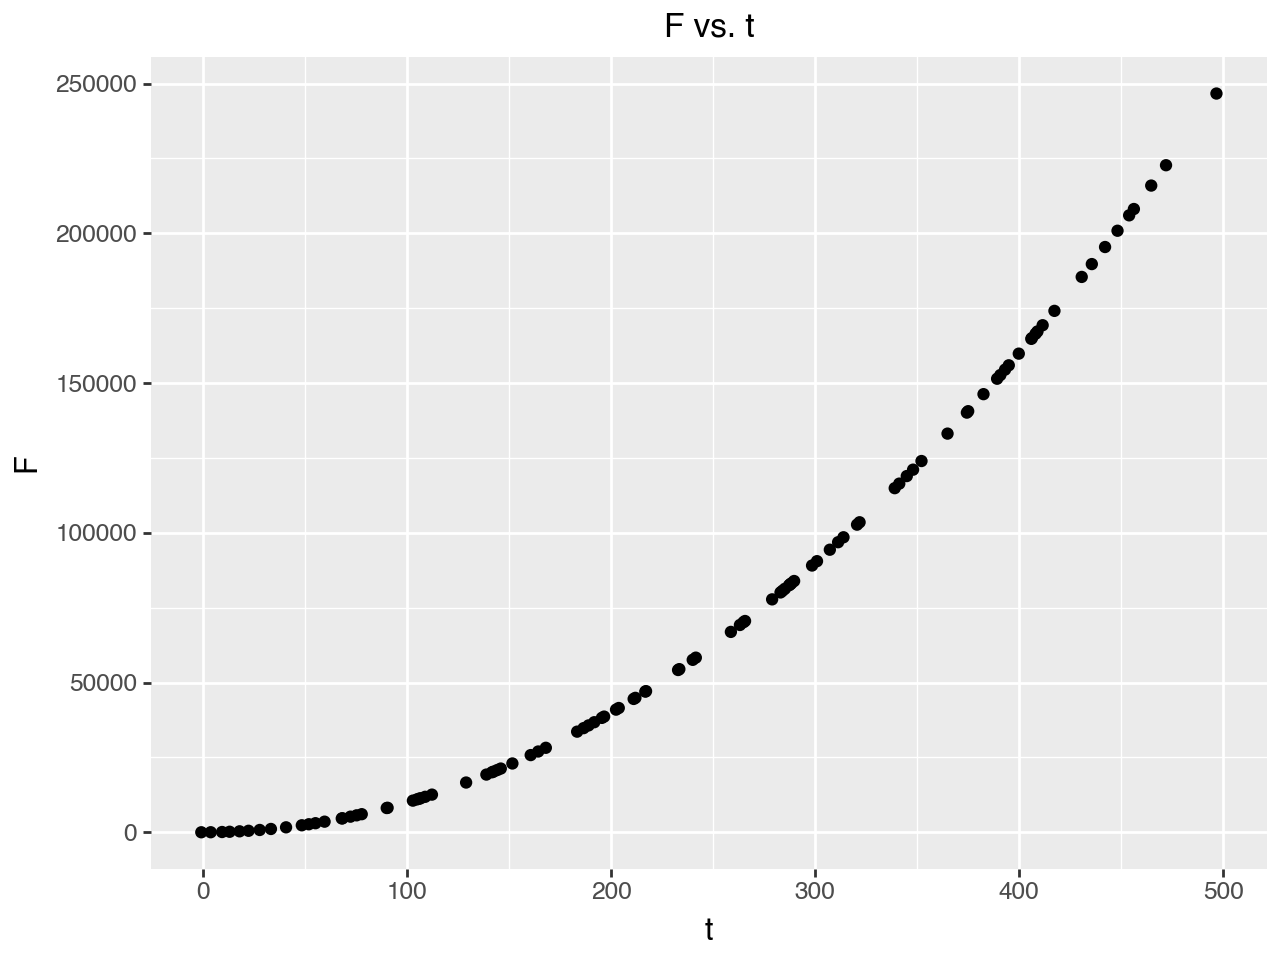

In [ ]:
records = []
for i in range(100):
    F, T = ss_decomp_ft(beta1=i)
    records.append({"F": F, "T": T})

df = pd.DataFrame(records)

# Scatter plot
(
    ggplot(df, aes(x="T", y="F"))
    + geom_point()
    + labs(title="F vs. t", x="t", y="F")
    + theme(plot_title=element_text(ha="center", size=12))
)

This looks like this could be part of a polynomial function like y = x^2. This is a good sign because F statistic and t statistic are relayed F = t^2